In [ ]:
# Setting up
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.legend_handler import HandlerBase
import numpy as np
import pandas as pd
import random


import scipy
import sys
import os
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()


import tskit
from matplotlib.lines import Line2D
datadir = "../data/"

# Track data files that are used for figures and write their paths to a text file at the end
_accessed = set()
def _track(fn):
    def wrapped(path, *a, **k):
        _accessed.add(os.path.abspath(path))
        return fn(path, *a, **k)
    return wrapped
pd.read_csv = _track(pd.read_csv)
np.load     = _track(np.load)
tskit.load  = _track(tskit.load)

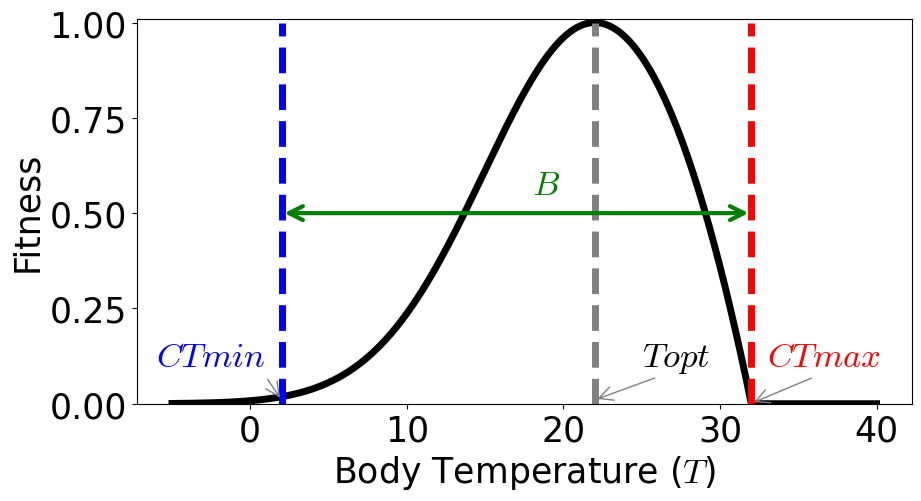

In [ ]:
# Figure 1A
Tlist = np.linspace(-5, 40, 400)
CTmin_example = 2
B_example = 30
w_enzymatic_example = tpc_object.w_enzymatic(CTmin=CTmin_example, B=B_example, T=Tlist)
w_tpc_example = tpc_object.w_TPC(CTmin=CTmin_example, B=B_example, T=Tlist)
CTmax_example = CTmin_example + B_example
Topt_example = CTmin_example + 2/3 * B_example

plt.rcParams.update({'font.size': 25})
plt.rcParams['mathtext.fontset'] = 'cm'
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Fitness")
ax.vlines(CTmin_example, ymin=0, ymax=1, linewidth=5, color='b', linestyle='--')
ax.text(-6, 0.1, r"$CTmin$", color='b')
ax.annotate("", xytext=(CTmin_example -1, 0.07), xy=(CTmin_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.text(18, 0.55, r"$B$", color='g')
ax.annotate("", xytext=(CTmin_example, 0.5), xy=(CTmin_example + B_example, 0.5),
            arrowprops=dict(arrowstyle="<->", color="g", linewidth=3))
ax.text(25, 0.1, r"$Topt$")
ax.vlines(CTmin_example + 2/3 * B_example, ymin=0, ymax=1, linewidth=5, color='grey', linestyle='--')
ax.annotate("", xytext=(Topt_example+4, 0.07), xy=(Topt_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))

ax.text(33, 0.1, r"$CTmax$", color='r')
ax.vlines(CTmax_example, ymin=0, ymax=1, linewidth=5, color='r', linestyle='--')
ax.annotate("", xytext=(CTmin_example+B_example+4, 0.07), xy=(CTmin_example+B_example, 0.001),
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.savefig(f"../figures/Fig1a_TPC_components_labeled.png", bbox_inches="tight")

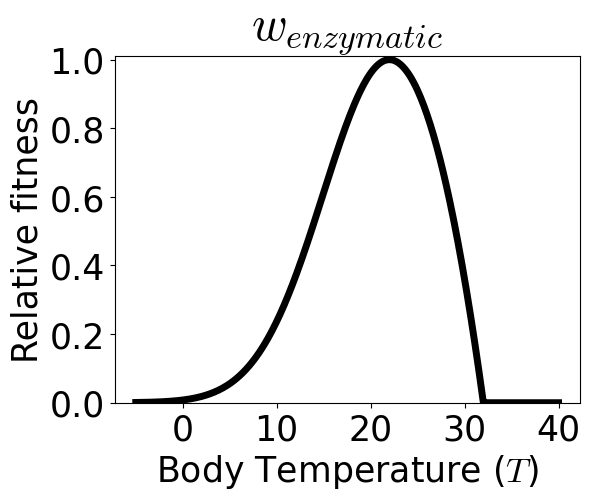

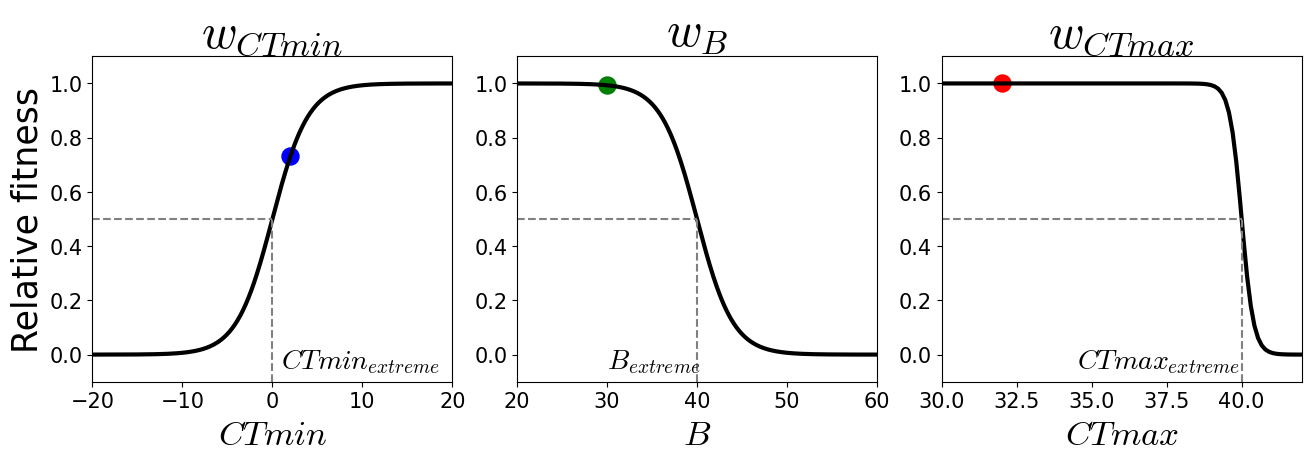

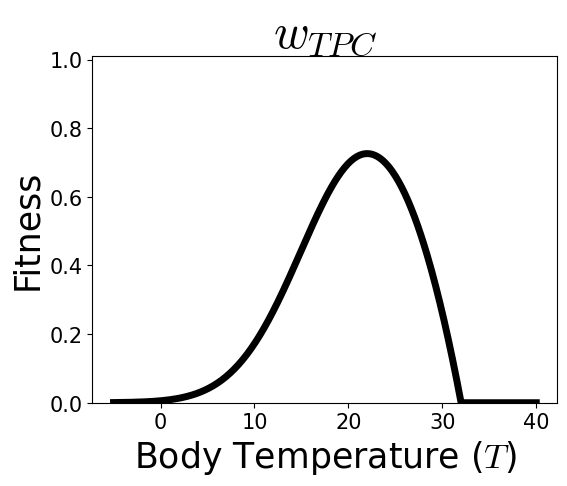

In [ ]:
# Figure 1B
fig, ax = plt.subplots(figsize=(6,4.5))
T_example = 20

ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Relative fitness")
ax.set_title(r"$w_{enzymatic}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_enzymatic.png", bbox_inches="tight")

plt.rcParams.update({'font.size': 15})
B_max = 40
DeltaB = 2
CTmin_min = 0
DeltaCTmin = 2
CTmax_max = 40
DeltaCTmax = 0.2
B_list = np.linspace(20, 60, 300)
CTmin_list = np.linspace(-20, 20, 400)
CTmax_list = np.linspace(30, 42, 100)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize = (13, 4.5), constrained_layout=True)

for ax in axes:
    ax.set_ylim((-0.1, 1.1))
# w_CTmin
# axes[0].set_ylabel("Fitness", fontsize=25)
axes[0].set_xlim((CTmin_list[0], CTmin_list[-1]))
axes[0].plot(CTmin_list, tpc_object.w_CTmin(CTmin=CTmin_list), color='k', linewidth=3)
axes[0].set_title(r"$w_{CTmin}$", fontsize=35)
axes[0].set_xlabel("$CTmin$", fontsize=25)
axes[0].set_ylabel("Relative fitness", fontsize=25)
axes[0].scatter(CTmin_example, tpc_object.w_CTmin(CTmin=CTmin_example), color='b', s=150)
axes[0].hlines(0.5, xmin=CTmin_list[0], xmax=CTmin_min, color='grey', linestyle='--')
axes[0].vlines(CTmin_min, ymin=-0.1, ymax=0.5, color='grey', linestyle='--')
axes[0].text(1, -0.05, r"$CTmin_{extreme}$", fontsize=20)

# w_B
axes[1].set_xlim((B_list[0], B_list[-1]))
axes[1].plot(B_list, tpc_object.w_B(B=B_list), color='k', linewidth=3)
axes[1].set_title(r"$w_{B}$", fontsize=35)
axes[1].set_xlabel("$B$", fontsize=25)
axes[1].scatter(B_example, tpc_object.w_B(B=B_example), color='g', s=150)
axes[1].hlines(0.5, xmin=B_list[0], xmax=B_max, color='grey', linestyle='--')
axes[1].vlines(B_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[1].text(B_max - 10, -0.05, r"$B_{extreme}$", fontsize=20)

# w_CTmax
axes[2].plot(CTmax_list, tpc_object.w_CTmax(CTmax=CTmax_list), color='k', linewidth=3)
axes[2].set_xlim((min(CTmax_list), max(CTmax_list)))
axes[2].set_title(r"$w_{CTmax}$", fontsize=35)
axes[2].set_xlabel("$CTmax$", fontsize=25)
axes[2].scatter(CTmax_example, tpc_object.w_CTmax(CTmax=CTmax_example), color='r', s=150)
axes[2].hlines(0.5, xmin=CTmax_list[0], xmax=CTmax_max, color='grey', linestyle='--')
axes[2].vlines(CTmax_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[2].text(CTmax_max - 5.5, -0.05, r"$CTmax_{extreme}$", fontsize=20)

fig.savefig("../figures/Fig1b_other_fitness_components.png", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6,4.5))

ax.plot(Tlist, tpc_object.w_TPC(B=B_example, CTmin=CTmin_example, T=Tlist), linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)", fontsize=25)
ax.set_ylabel("Fitness", fontsize=25)

ax.set_title(r"$w_{TPC}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_TPC.png", bbox_inches="tight")

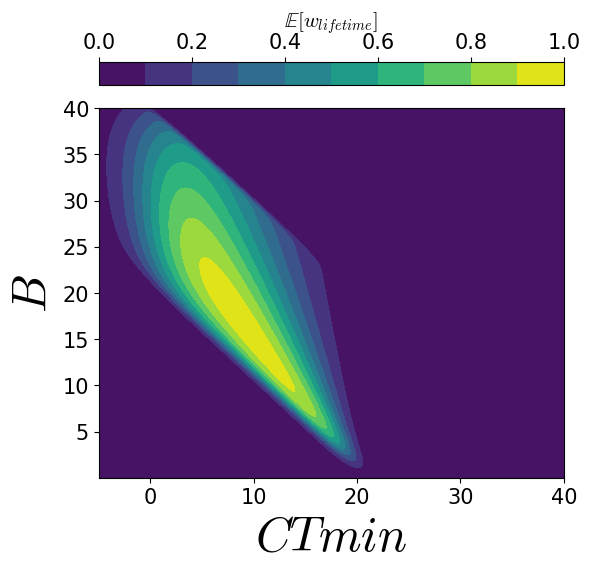

In [ ]:
# Figure 1D
analytical_info = np.load("../data/gaussian_MEAN_TEMP_20_STDEV_TEMP_1_analytical_info.npz", allow_pickle=True)
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels=np.linspace(0, 1, 11))
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig("../figures/Fig1d_fitness_landscape.png", bbox_inches='tight')

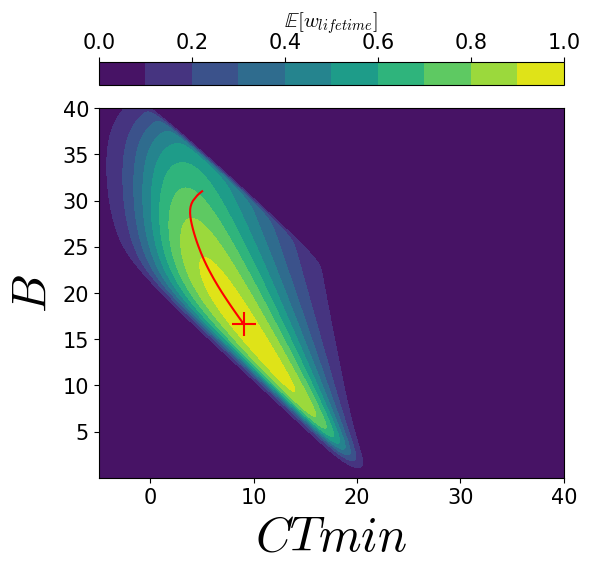

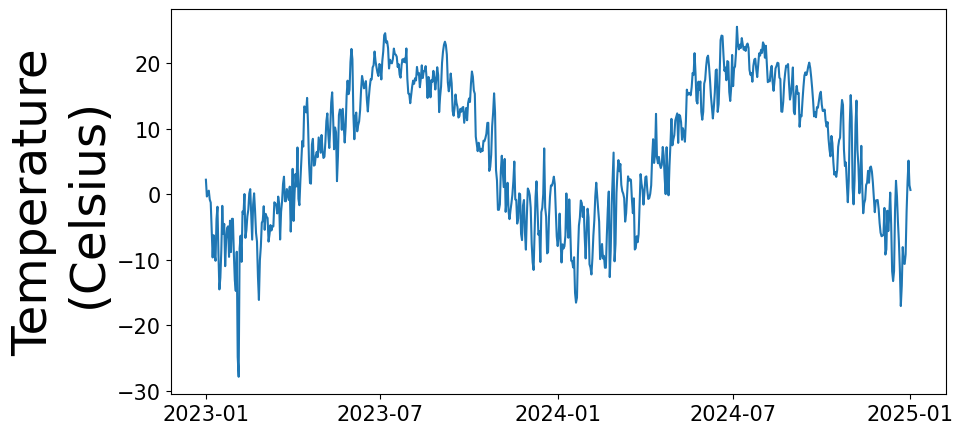

In [ ]:
# Figure 1E
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels = np.linspace(0, 1, 11))
ax.plot(analytical_info['sol'].item().y[0], analytical_info['sol'].item().y[1], color='red')
ax.scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], marker='+', s = 300, color='red')
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig('../figures/Fig1e_trajectory.png', bbox_inches='tight')

VT_temps = pd.read_csv("../slim/VT_weather.txt")

fig, ax = plt.subplots(figsize=(10, 5))

VT_temps["YYYYMMDD"] = pd.to_datetime(VT_temps["YYYYMMDD"])
start_date = pd.Timestamp("2023-01-01")
end_date = pd.Timestamp("2025-01-01")
daily_t2m_vt = VT_temps[(VT_temps["YYYYMMDD"] >= start_date) & (VT_temps["YYYYMMDD"] <= end_date)]

ax.plot(
    daily_t2m_vt["YYYYMMDD"],
    daily_t2m_vt["T2M"],

)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_ylabel("Temperature\n(Celsius)", fontsize=35)
fig.savefig("../figures/Fig1e_timeseries.png", bbox_inches='tight')

muT=5, sigmaT=1
muT=5, sigmaT=3
muT=20, sigmaT=1
muT=20, sigmaT=3
muT=35, sigmaT=1
muT=35, sigmaT=3


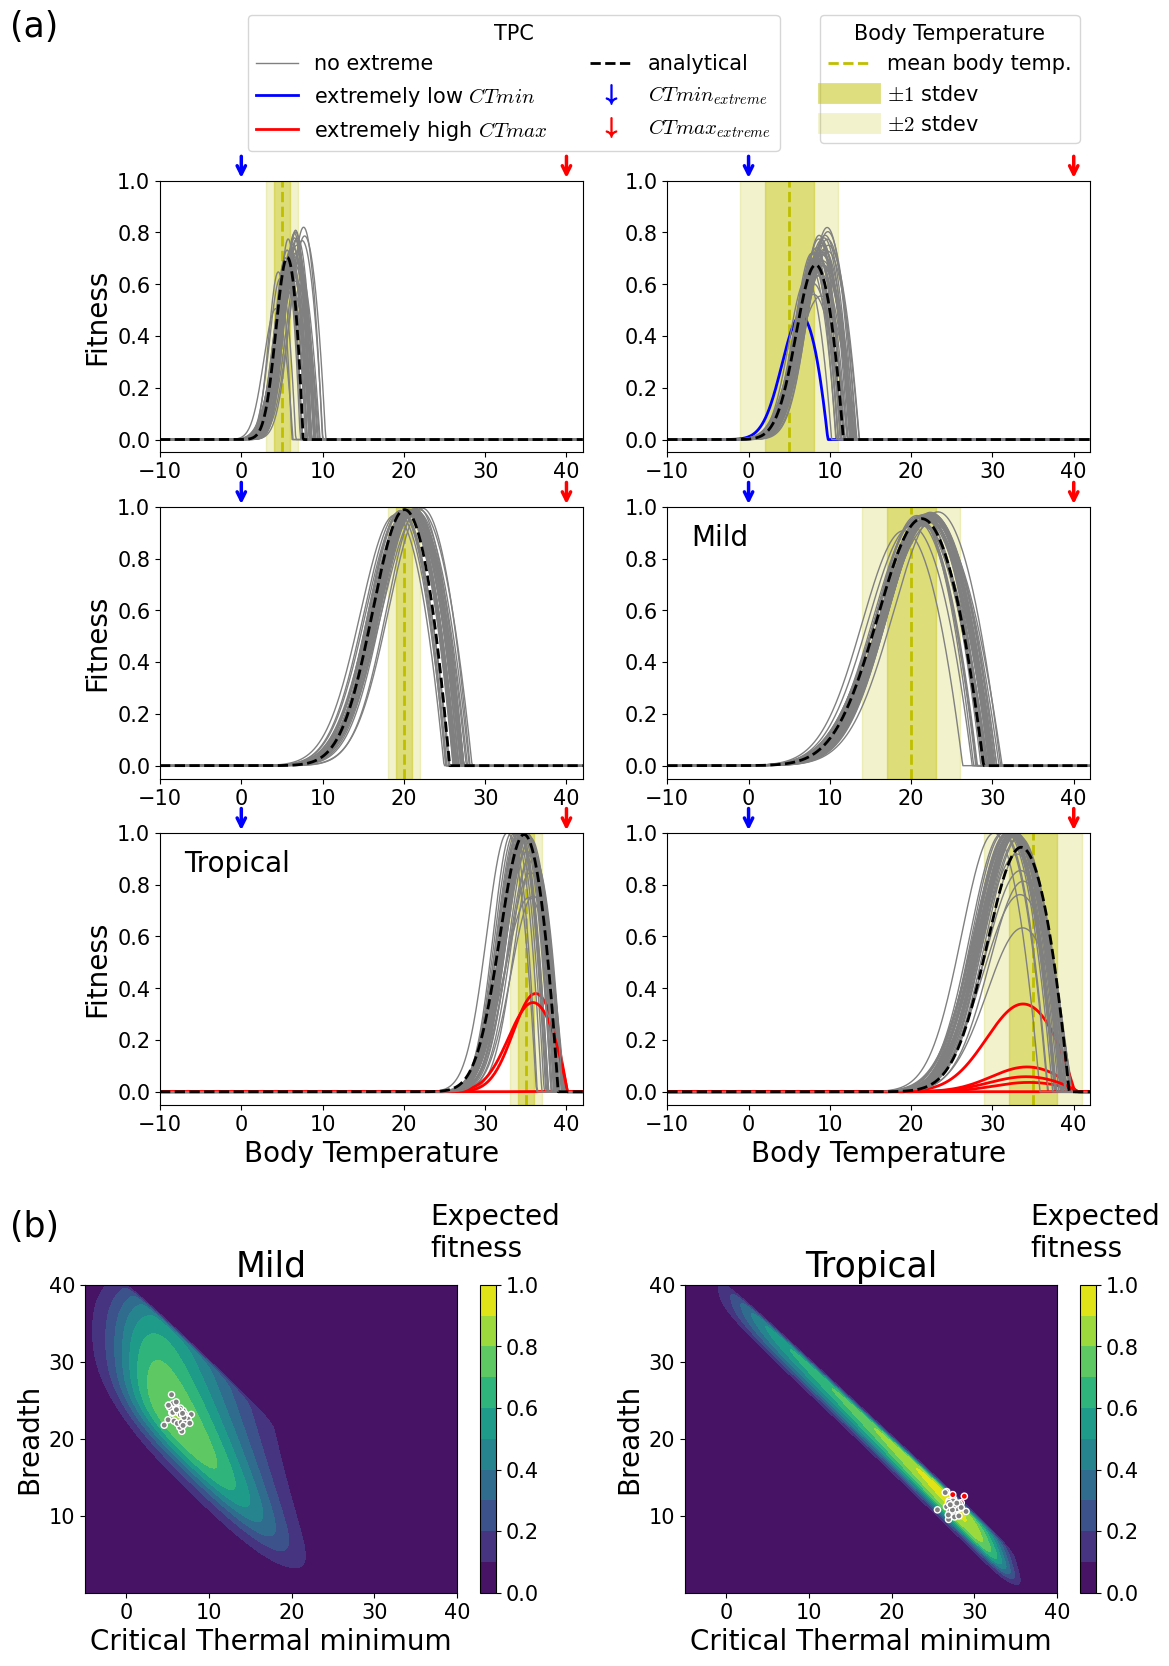

In [ ]:
# Figure 2
plt.rcParams.update({'font.size': 15})
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params_sub = params[(params.seed == 29)]
params_sub = params_sub.sort_values(by=['MEAN_TEMP', 'STDEV_TEMP']).reset_index(drop=True)
muTs = params_sub.MEAN_TEMP.unique()
sigmaTs = [1, 3]

fig = plt.figure(figsize=(12, 16))
fig.tight_layout(rect=(0,0,0.7,0.9))


subfigs = fig.subfigures(2, 1, hspace = 0.07, height_ratios=[3,1])
subsubfigs = subfigs[1].subfigures(1, 2, wspace=0.07, width_ratios=[1,1])
subfigs[0].text(0, 1, "(a)", fontsize=25)
subsubfigs[0].text(0, 1, "(b)", fontsize=25)


ax_top = subfigs[0].subplots(nrows = len(muTs), ncols = len(sigmaTs))
T_series = np.linspace(-10, 42, 500)

threshold = 0.5 # threshold for coloring - when the parameter is within critical value
for i, muT in enumerate(muTs):
    for j, sigmaT in enumerate(sigmaTs):
        print(f"muT={muT}, sigmaT={sigmaT}")
        ax_top[i, j].vlines(muT, ymin=-0.05, ymax=1.05, linestyle='--', linewidth=2, color='y')
        ax_top[i, j].axvspan(muT-2*sigmaT, muT+2*sigmaT, color='y', alpha=0.2)
        ax_top[i, j].axvspan(muT-sigmaT, muT+sigmaT, color='y', alpha=0.4)
        ax_top[i, j].set_ylim((-0.05, 1))
        ax_top[i, j].set_xlim((min(T_series), max(T_series)))
        if j == 0:
            ax_top[i,j].set_ylabel(f"Fitness", fontsize=20)
        if i == len(muTs)-1:
            ax_top[i,j].set_xlabel("Body Temperature", fontsize=20)
tropical_Bs= []
tropical_CTmins = []
tropical_colors = []
mild_Bs = []
mild_CTmins = []
mild_colors = []

for index, row in params_sub.iterrows():
    # locate muT and sigmaT in the unique list
    if row.STDEV_TEMP in sigmaTs:
        i = list(muTs).index(row.MEAN_TEMP)
        j = list(sigmaTs).index(row.STDEV_TEMP)
        B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
        Bs_final = np.array(B_and_CTmin.B)
        CTmins_final = np.array(B_and_CTmin.CTmin)
        random.seed(4)
        sample_idx = random.sample(range(len(Bs_final)), 40)
        for B, CTmin in zip(Bs_final[sample_idx], CTmins_final[sample_idx]):
            w_CTmin = tpc_object.w_CTmin(CTmin)
            w_B = tpc_object.w_B(B)
            CTmax = CTmin + B
            w_CTmax = tpc_object.w_CTmax(CTmax)
            if (w_B < threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
                # Too generalist
                color = 'g'
                linewidth = 2
            elif (w_CTmin < threshold) and (w_B > threshold) and (w_CTmax > threshold):
                # Too much cold adaptation
                color = 'b'
                linewidth = 2
            elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax < threshold):
                # Too much heat adaptation
                color = 'r'
                linewidth = 2
            elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
                # not limited by any of 3 physiological constraints
                color = 'grey'
                linewidth = 1
            else:
                print("constrained by more than one types of limits")
                continue
            ax_top[i, j].plot(T_series, tpc_object.w_TPC(CTmin=CTmin, B=B, T=T_series), 
                        linewidth=linewidth, 
                        color=color)
            # save B, CTmin and color for subfigure (B) and (C) if mild or tropic
            if i == 1 and j == 1:
                mild_Bs.append(B)
                mild_CTmins.append(CTmin)
                mild_colors.append(color)
            elif i == 2 and j == 0:
                tropical_Bs.append(B)
                tropical_CTmins.append(CTmin)
                tropical_colors.append(color)
        analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_analytical_info.npz", allow_pickle=True)
        ax_top[i,j].plot(T_series, tpc_object.w_TPC(CTmin=analytical_info['CTmin_opt'], B=analytical_info['B_opt'], T=T_series), 
                        linewidth=2, 
                        color='k', 
                        linestyle='--')
        # Blue arrow at T=0 pointing down to the top border (Fitness=1)
        ax_top[i, j].annotate('', xy=(0, 1.0), xytext=(0, 1.1),
                            xycoords=('data', 'axes fraction'),
                            textcoords=('data', 'axes fraction'),
                            annotation_clip=False,
                            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5),
                            clip_on=False)
        # Red arrow at T=40 pointing down to the top border (Fitness=1)
        ax_top[i, j].annotate('', xy=(40, 1.0), xytext=(40, 1.1),
                            xycoords=('data', 'axes fraction'),
                            textcoords=('data', 'axes fraction'),
                            annotation_clip=False,
                            arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
                            clip_on=False)

# Label "tropical" and "mild"
ax_top[2, 0].text(-7, 0.85, "Tropical", fontsize=20)
ax_top[1, 1].text(-7, 0.85, "Mild", fontsize=20)
# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='grey', linewidth=1, label='no extreme'),
    Line2D([0], [0], color='blue', linewidth=2, label='extremely low $CTmin$'),
    Line2D([0], [0], color='red', linewidth=2, label='extremely high $CTmax$'),
    Line2D([0], [0], color='k', linewidth=2, linestyle='--', label='analytical'),
    Line2D([0], [0], color='blue', linestyle='None', marker=r'$\downarrow$', markersize=14, label='$CTmin_{extreme}$'),
    Line2D([0], [0], color='red', linestyle='None', marker=r'$\downarrow$', markersize=14, label='$CTmax_{extreme}$')]

legend_handles2 = [
    Line2D([0], [0], color='y', linewidth=2, linestyle='--', label='mean body temp.'),
    Line2D([0], [0], color='y', alpha=0.5, linewidth=15, label='$\\pm 1$ stdev'),
    Line2D([0], [0], color='y', alpha=0.2, linewidth=15, label='$\\pm 2$ stdev'), 
]

# Test legend outside the subplots
fig.legend(handles=legend_handles, bbox_to_anchor=(0.65,1.02), ncols=2, title='TPC')
fig.legend(handles=legend_handles2, bbox_to_anchor=(0.9, 1.02), title="Body Temperature")


# Subfigure 2: fitness landscape for tropical vs. mild
ax_bottom_left = subsubfigs[0].subplots(nrows=1, ncols = 1)
analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_20_STDEV_TEMP_3_analytical_info.npz", allow_pickle=True)

contour = ax_bottom_left.contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  levels=np.linspace(0, 1, 11),
                                  cmap='viridis')


ax_bottom_left.set_xlabel("Critical Thermal minimum", fontsize=20)
ax_bottom_left.set_ylabel("Breadth", fontsize=20)
ax_bottom_left.set_title("Mild", fontsize=25)
fig.colorbar(contour, ax=ax_bottom_left)
subsubfigs[0].text(0.7, 0.95, "Expected\nfitness", fontsize=20)
ax_bottom_left.scatter(mild_CTmins, mild_Bs, marker='o', edgecolor='w', facecolor=mild_colors, s=20)

ax_bottom_right = subsubfigs[1].subplots(nrows=1, ncols = 1)

analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_35_STDEV_TEMP_1_analytical_info.npz", allow_pickle=True)

contour = ax_bottom_right.contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'],
                                  levels=np.linspace(0, 1, 11), 
                                  cmap='viridis')
ax_bottom_right.set_xlabel("Critical Thermal minimum", fontsize=20)
ax_bottom_right.set_ylabel("Breadth", fontsize=20)
ax_bottom_right.set_title("Tropical", fontsize=25)
subsubfigs[1].text(0.7, 0.95, "Expected\nfitness", fontsize=20)
fig.colorbar(contour, ax=ax_bottom_right)
ax_bottom_right.scatter(tropical_CTmins, tropical_Bs, marker='o', edgecolor='w', facecolor=tropical_colors, s=20)
fig.savefig('../figures/Fig2_sample_tpcs.pdf', bbox_inches='tight')

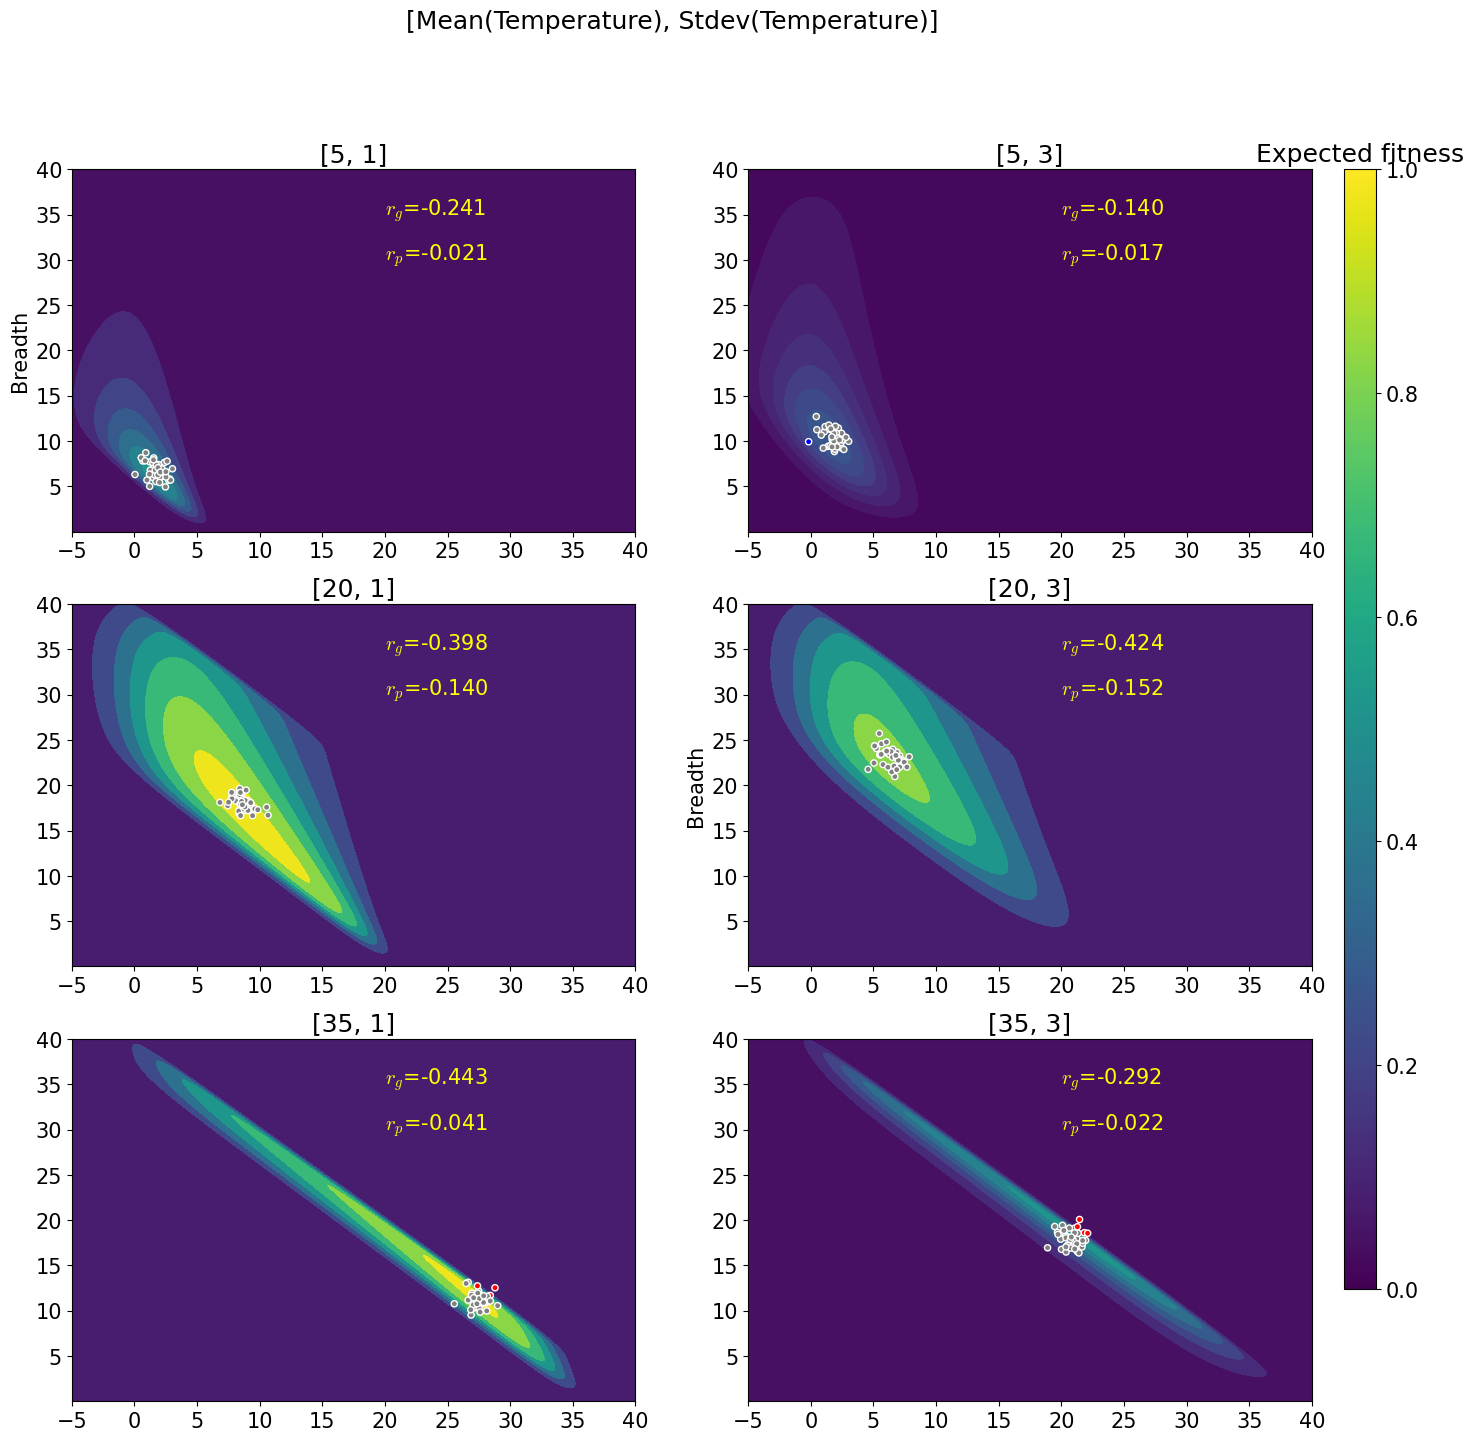

In [ ]:
# Figure 3
plt.rcParams.update({'font.size': 15})
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params_sub = params[(params.seed == 29)]
params_sub = params_sub.sort_values(by=['MEAN_TEMP', 'STDEV_TEMP']).reset_index(drop=True)

muTs = params_sub.MEAN_TEMP.unique()
sigmaTs = params_sub.STDEV_TEMP.unique()
fig, ax = plt.subplots(figsize=(16, 16), nrows=3, ncols=2)
fig.suptitle("[Mean(Temperature), Stdev(Temperature)]")
threshold = 0.5 # threshold for coloring - when the parameter is within critical value

for i, subax in enumerate(ax.flat):
    if i%3==0:
        subax.set_ylabel("Breadth")
    if i>=6:
        subax.set_xlabel("Critical Thermal minimum")
    
for index, row in params_sub.iterrows():
    # locate muT and sigmaT in the unique list
    i = list(muTs).index(row.MEAN_TEMP)
    j = list(sigmaTs).index(row.STDEV_TEMP)
    B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
    analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_analytical_info.npz", allow_pickle=True)

    Bs_final = np.array(B_and_CTmin.B)
    CTmins_final = np.array(B_and_CTmin.CTmin)
    random.seed(4)
    sample_idx = random.sample(range(len(Bs_final)), 40)
    colors = []
    for B, CTmin in zip(Bs_final[sample_idx], CTmins_final[sample_idx]):
        w_CTmin = tpc_object.w_CTmin(CTmin)
        w_B = tpc_object.w_B(B)
        CTmax = CTmin + B
        w_CTmax = tpc_object.w_CTmax(CTmax)
        if (w_B < threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
            # Too generalist
            color = 'g'
            alpha = 1
        elif (w_CTmin < threshold) and (w_B > threshold) and (w_CTmax > threshold):
            # Too much cold adaptation
            color = 'b'
            alpha = 1
        elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax < threshold):
            # Too much heat adaptation
            color = 'r'
            alpha = 1
        elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
            # not limited by any of 3 physiological constraints
            color = 'grey'
            alpha = 1
        else:
            print("constrained by more than one types of limits")
            continue
        colors.append(color)


    contour = ax[i,j].contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  vmin=0, vmax=1, 
                                  cmap='viridis')
    ax[i,j].scatter(CTmins_final[sample_idx], Bs_final[sample_idx], marker='o', edgecolor='w', facecolor=colors, s=20)
    ax[i,j].set_title(f"[{row.MEAN_TEMP}, {row.STDEV_TEMP}]")
    
    # Calculate genetic covariance (sum of effect sizes in QTN_CTmin vs. QTN_B)
    ts = tskit.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.trees")
    G_CTmin_list = np.zeros(ts.num_individuals)
    G_B_list = np.zeros(ts.num_individuals)
    
    var_idx = 0
    for var in ts.variants():
        gene_dose = var.genotypes[::2] + var.genotypes[1::2]
        s = var.site.mutations[0].metadata['mutation_list'][0]['selection_coeff']
        if var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 2:
        # m2, i.e. QTN for B
            G_B_list += gene_dose * s
        elif var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 3:
            G_CTmin_list += gene_dose * s
        else:
            print("undefined mutation type")
        var_idx += 1

    g_corr = np.corrcoef(G_B_list, G_CTmin_list)[0,1]
    ax[i,j].text(20, 35, f"$r_g$={g_corr:.3f}", color='yellow')
    p_corr = np.corrcoef(Bs_final, CTmins_final)[0,1]
    ax[i,j].text(20, 30, f"$r_p$={p_corr:.3f}", color='yellow')
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap='viridis'),
             cax=cbar_ax, orientation='vertical')
cbar_ax.set_title("Expected fitness")
fig.savefig("../figures/SI_Fig2_sample_TPCs_on_fitness_landscape.pdf", bbox_inches='tight')

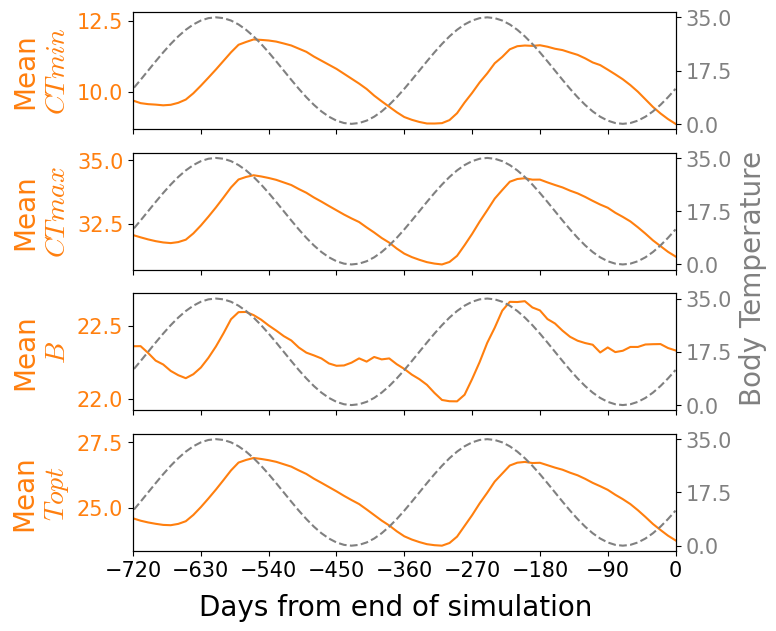

In [ ]:
# Figure 4
CTmin_critical = 0
B_critical = 20
log = pd.read_csv(f"{datadir}sine_test_CTmin_critical_{CTmin_critical}_B_critical_{B_critical}.txt")
# Use only the last 10 years of the data (1 yr = 360 days in this example)
log['day_from_end_of_sim'] = log.day - max(log.day)
log2 = log[log.day_from_end_of_sim > - 3601]

fig, ax = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
ylist = [log2.CTmin_mean, log2.CTmax_mean, log2.B_mean, log2.Topt_mean]
ylabels = [ "Mean\n"+r"$CTmin$", "Mean\n"+r"$CTmax$", "Mean\n"+r"$B$", "Mean\n"+r"$Topt$"]
fig.supxlabel("Days from end of simulation", fontsize=20)
fig.supylabel("Body Temperature", x=1.03, ha='right', va='center', color='grey', fontsize=20)
for i in range(4):
    ax[i].plot(log2.day_from_end_of_sim, ylist[i], color="tab:orange")
    ax[i].set_xlim((-720, 0))
    ax[i].set_xticks(np.arange(-720, 1, 90))
    ax[i].set_ylabel(ylabels[i], color="tab:orange", fontsize=20)
    ax[i].tick_params(axis='y', labelcolor='tab:orange')
    ax2 = ax[i].twinx()
    ax2.plot(log2.day_from_end_of_sim, log2.Temp, color="grey", linestyle="--")
    ax2.set_yticks(np.arange(0, 35.2, 17.5))
    ax2.tick_params(axis='y', labelcolor='grey')

fig.savefig("../figures/Fig3_sinusoidal.pdf", bbox_inches='tight')

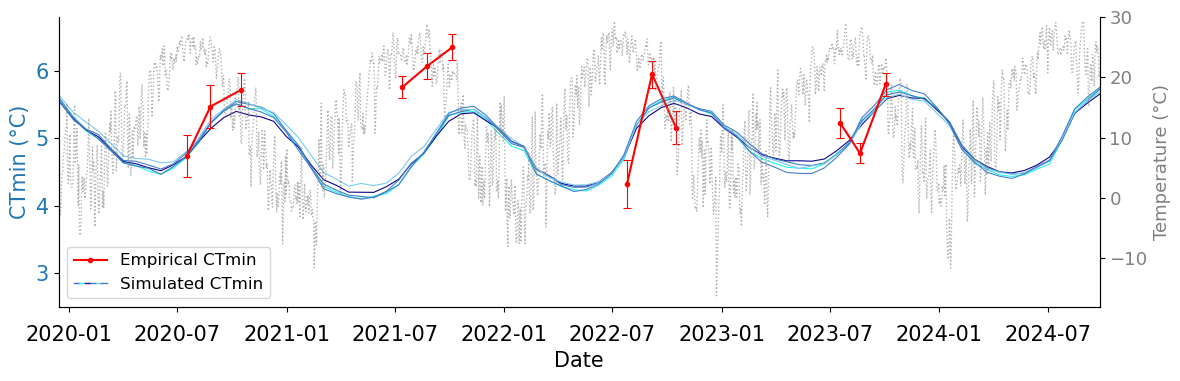

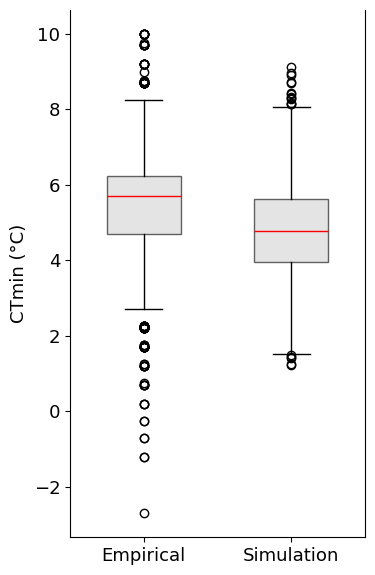

In [ ]:
# Figure 4


# to get trees for boxplot (flexible for names of .trees files)
TP_INFO = {
    'tp1_9':  {'date': '2023-07-19', 'year': 2023, 'timepoint': 'First'},
    'tp2_9':  {'date': '2023-08-21', 'year': 2023, 'timepoint': 'Second'},
    'tp3_9':  {'date': '2023-10-03', 'year': 2023, 'timepoint': 'Third'},
    'tp4_9':  {'date': '2022-07-26', 'year': 2022, 'timepoint': 'First'},
    'tp5_9':  {'date': '2022-09-06', 'year': 2022, 'timepoint': 'Second'},
    'tp6_9':  {'date': '2022-10-16', 'year': 2022, 'timepoint': 'Third'},
    'tp7_9':  {'date': '2021-07-14', 'year': 2021, 'timepoint': 'First'},
    'tp8_9':  {'date': '2021-08-25', 'year': 2021, 'timepoint': 'Second'},
    'tp9_9':  {'date': '2021-10-06', 'year': 2021, 'timepoint': 'Third'},
    'tp10_9': {'date': '2020-07-17', 'year': 2020, 'timepoint': 'First'},
    'tp11_9': {'date': '2020-08-26', 'year': 2020, 'timepoint': 'Second'},
    'tp12_9': {'date': '2020-10-17', 'year': 2020, 'timepoint': 'Third'},
}

# simulation replicates (flexible file path)
SIM_REPLICATES = {
    'rep1': {'file': f'{datadir}/tp1_7.txt', 'color': '#22f5e7'},
    'rep2': {'file': f'{datadir}/tp2_7.txt', 'color': '#0e038a'},
    'rep3': {'file': f'{datadir}/tp3_7.txt', 'color': '#3e7ec7'},
    'rep4': {'file': f'{datadir}/tp4_7.txt', 'color': '#78ccf0'},
    'rep5': {'file': f'{datadir}/tp5_7.txt', 'color': '#477ed1'},
}

PLOT_XLIM = ('2019-12-15', '2024-09-26')
PLOT_YLIM_CTMIN = (2.5, 6.8)
PLOT_YLIM_TEMP  = (-18, 30)
SIM_ROW_SLICE   = slice(20200, 20301) # getting the final simulation CTmins from the four-year empirical window

def load_empirical_ctmin(ctmin_path: str, temp_path):
    """load and aggregate F4-generation empirical CTmin data
    ctmin_path: str (path to empirical CTmin data)
    temp_path: str (path to temperature time series)
    returns: dataframe
    """
    df_temp  = pd.read_csv(temp_path, parse_dates=['YYYYMMDD'])
    df_ctmin = pd.read_csv(ctmin_path).rename(columns={"Year ": "Year"})
    df_ctmin['Collection Date'] = pd.to_datetime(df_ctmin['Collection Date'])

    f4 = df_ctmin[df_ctmin['Generation'] == 'F4 '].copy()
    agg = (
        f4.groupby(['Collection Date', 'Time point'])
          .agg(CTmin_mean=('temp', 'mean'), CTmin_sd=('temp', 'std'), n=('temp', 'count'))
          .reset_index()
          .merge(df_temp[['YYYYMMDD']], left_on='Collection Date', right_on='YYYYMMDD', how='inner')
    )
    agg['Year'] = agg['Collection Date'].dt.year

    result = (
        agg.groupby(['Year', 'Time point'])
           .agg(Collection_Date=('Collection Date', 'first'),
                CTmin_mean=('CTmin_mean', 'mean'),
                CTmin_sd=('CTmin_sd', 'mean'),
                n=('n', 'sum'))
           .reset_index()
    )
    tp_order = ["First", "Second", "Third"]
    result['Time point'] = pd.Categorical(result['Time point'], categories=tp_order, ordered=True)
    result = result.sort_values(['Year', 'Time point']).reset_index(drop=True)
    result['x'] = range(len(result))
    return result, df_temp, f4

def load_replicate(path, real_dates, row_slice: slice = SIM_ROW_SLICE):
    """load a simulation replicate, map sim days to real calendar dates, slice desired window of dates
    path: str (path to simulation replicate file)
    real_dates: series (mapping julien day to real date)
    row_slice: slice (indices corresponding to desired dates)
    returns: dataframe
    """
    df = pd.read_csv(path).sort_values('day').reset_index(drop=True)
    df['sim_day_index'] = df['day'] - df['day'].min()
    df['date'] = df['sim_day_index'].apply(lambda x: real_dates.iloc[x % len(real_dates)])
    return df.iloc[row_slice]

def load_sim_trees(tp_info, data_dir = 'data'):
    """extract CTmin values from all tree files into a df
    tp_info: dict (contains filename and info on sampling timepoint)
    data_dir: str (path to data folder holding tree files)
    returns: dataframe
    """
    records = [
        {'CTmin': val, 'date': info['date'], 'year': info['year'],
         'timepoint': info['timepoint'], 'source': 'Simulation'}
        for tp, info in tp_info.items()
        for val in tskit.load(f"{data_dir}/{tp}.trees")
                        .metadata['SLiM']['user_metadata']['CTmins_final']
    ]
    return pd.DataFrame(records)

class HandlerMultiColorLines(HandlerBase):
    """legend handler that draws a segmented multi-color line"""
    def __init__(self, colors, linewidth=1, **kwargs):
        self.colors, self.linewidth = colors, linewidth
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        n = len(self.colors)
        return [
            Line2D(
                [xdescent + i * width / n, xdescent + (i + 1) * width / n],
                [ydescent + height / 2] * 2,
                color=c, linewidth=self.linewidth, transform=trans
            )
            for i, c in enumerate(self.colors)
        ]

def plot_ctmin_timeseries(f4_ctmin, df_temp, replicates, save_path='ctmin_timeseries.png'):
    """plot empirical + simulated CTmin over time with a temperature background."""
    fig, ax1 = plt.subplots(figsize=(12, 4))
    plt.rcParams.update({'font.size': 13, 'axes.spines.top': False})
    ax1.tick_params(axis='x', pad=10)

    # temperature on right axis
    ax2 = ax1.twinx()
    ax2.plot(df_temp['YYYYMMDD'], df_temp['T2M'],
             color='grey', linestyle='dotted', linewidth=1, alpha=.6, zorder=1)
    ax2.set_ylabel('Temperature (°C)', color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.set_ylim(*PLOT_YLIM_TEMP)
    ax2.spines['top'].set_visible(False)

    # empirical CTmin with +/- 2 se error bars
    for year, g in f4_ctmin.groupby('Year'):
        ax1.errorbar(
            g['Collection_Date'], g['CTmin_mean'],
            yerr=2 * g['CTmin_sd'] / np.sqrt(g['n']),
            color='red', linewidth=1.5, marker='.', linestyle='-',
            elinewidth=0.8, ecolor='red', capsize=3, capthick=0.8, zorder=7,
            label='Empirical CTmin' if year == f4_ctmin['Year'].min() else None
        )

    # simulation replicates
    for rep in replicates.values():
        ax1.plot(rep['df']['date'], rep['df']['CTmin_mean'],
                 color=rep['color'], linewidth=0.8, linestyle='-', zorder=6)

    ax1.spines['top'].set_visible(False)
    ax1.set_ylabel('CTmin (°C)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(*PLOT_YLIM_CTMIN)
    ax1.set_xlim(pd.to_datetime(PLOT_XLIM[0]), pd.to_datetime(PLOT_XLIM[1]))
    ax1.set_xlabel('Date')

    # legend
    all_colors = ['royalblue'] + [r['color'] for r in replicates.values()]
    sim_handle = Line2D([], [], color='black', linewidth=1, label='Simulated CTmin')
    ax1.legend(
        handles=[Line2D([], [], color='red', marker='.', linestyle='-',
                               linewidth=1.5, label='Empirical CTmin'), sim_handle],
        handler_map={sim_handle: HandlerMultiColorLines(all_colors, linewidth=1)},
        loc='lower left', fontsize=12
    )
    fig.tight_layout()
    plt.savefig(save_path, dpi=300)

def plot_boxplot_comparison(emp_values, sim_values, save_path='boxplot_comparison.png'):
    """side-by-side boxplot of empirical vs simulated CTmin"""
    fig, ax = plt.subplots(figsize=(4, 6))
    plt.rcParams.update({'font.size': 15})
    bp = ax.boxplot(
        [emp_values, sim_values],
        tick_labels=['Empirical', 'Simulation'],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=1),
        widths=0.5
    )
    for box in bp['boxes']:
        box.set_facecolor('lightgrey')
        box.set_alpha(0.6)
    ax.set_ylabel('CTmin (°C)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)

if __name__ == '__main__':
    # load empirical data
    f4_ctmin, df_temp, df_f4 = load_empirical_ctmin(f'{datadir}/CTminSeasonality.csv', '../slim/KY_timeseries.csv')
    real_dates = df_temp['YYYYMMDD'].reset_index(drop=True)

    # load simulation replicates
    replicates = {
        name: {**cfg, 'df': load_replicate(cfg['file'], real_dates)}
        for name, cfg in SIM_REPLICATES.items()
    }

    # load simulation trees
    sim_df = load_sim_trees(TP_INFO, data_dir=datadir)

    # plots
    plot_ctmin_timeseries(f4_ctmin, df_temp, replicates, save_path='../figures/Fig4-ctmin_timeseries.png')
    plot_boxplot_comparison(df_f4['temp'].values, sim_df['CTmin'].values,
                            save_path='../figures/Fig4-boxplot.png')

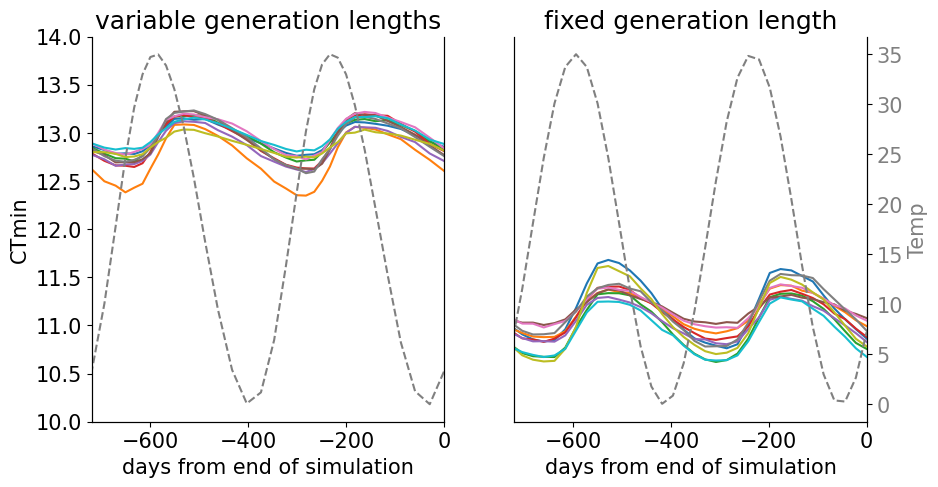

In [ ]:
# Figure 6

sine3_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine3_params.csv")
kinds = ['T', 'F']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ax2 = [None, None]
def plot_sine3(row):
    if row.seed < 10:
        if os.path.isfile(f"{datadir}/{row.OUTNAME}.trees"):
            log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
            i = kinds.index(row.GEN_LEN_DEPENDS_ON_TEMP)
            ax.flat[i].plot(log.day - max(log.day), log.CTmin_mean)
        if row.seed == 0:
            ax2[i] = ax[i].twinx()
            ax2[i].plot(log.day - max(log.day), log.Temp, color="grey", linestyle="--")
            ax2[i].tick_params(axis='y', labelcolor='grey')
    
sine3_params.apply(plot_sine3, axis=1)

for i, kind in enumerate(['T', 'F']):
    ax.flat[i].set_xlim((-720, 0))
    ax.flat[i].set_ylim((10, 14))
    ax[i].set_xlabel("days from end of simulation")
    if kind == 'T':
        ax[i].set_title("variable generation lengths")
    else: 
        ax[i].set_title("fixed generation length")
    if i != 0:
        ax[i].set_yticks([])
    if i != 1:
        ax2[i].set_yticks([])
ax[0].set_ylabel('CTmin')
ax2[1].set_ylabel('Temp', color='grey')
   

fig.savefig("../figures/variable_vs_fixed_gen.png", bbox_inches='tight')

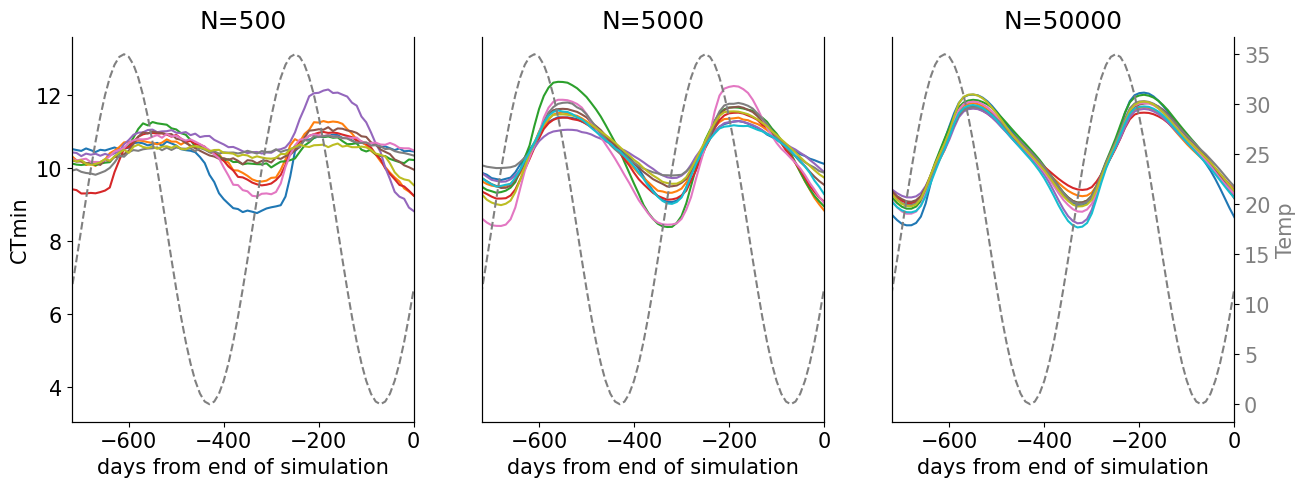

In [ ]:
# Figure 7(a)

sine2_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine2_params.csv")
Ns = sine2_params.N_POP.unique()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax2 = [None, None, None]
def plot_sine2(row):
    if row.seed < 10:
        if os.path.isfile(f"{datadir}/{row.OUTNAME}.trees"):
            log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
            i = list(Ns).index(row.N_POP)
            ax.flat[i].plot(log.day - max(log.day), log.CTmin_mean)
        if row.seed == 0:
            ax2[i] = ax[i].twinx()
            ax2[i].plot(log.day - max(log.day), log.Temp, color="grey", linestyle="--")
            ax2[i].tick_params(axis='y', labelcolor='grey')
    
sine2_params.apply(plot_sine2, axis=1)

for i, N in enumerate(Ns):
    ax.flat[i].set_xlim((-720, 0))
    # ax.flat[i].set_ylim((2, 3.8))
    ax[i].set_xlabel("days from end of simulation")
    ax[i].set_title(f"N={N}")
    if i != 0:
        ax[i].set_yticks([])
    if i != 2:
        ax2[i].set_yticks([])
ax[0].set_ylabel('CTmin')
ax2[2].set_ylabel('Temp', color='grey')
fig.savefig("../figures/changing_N.png", bbox_inches='tight')

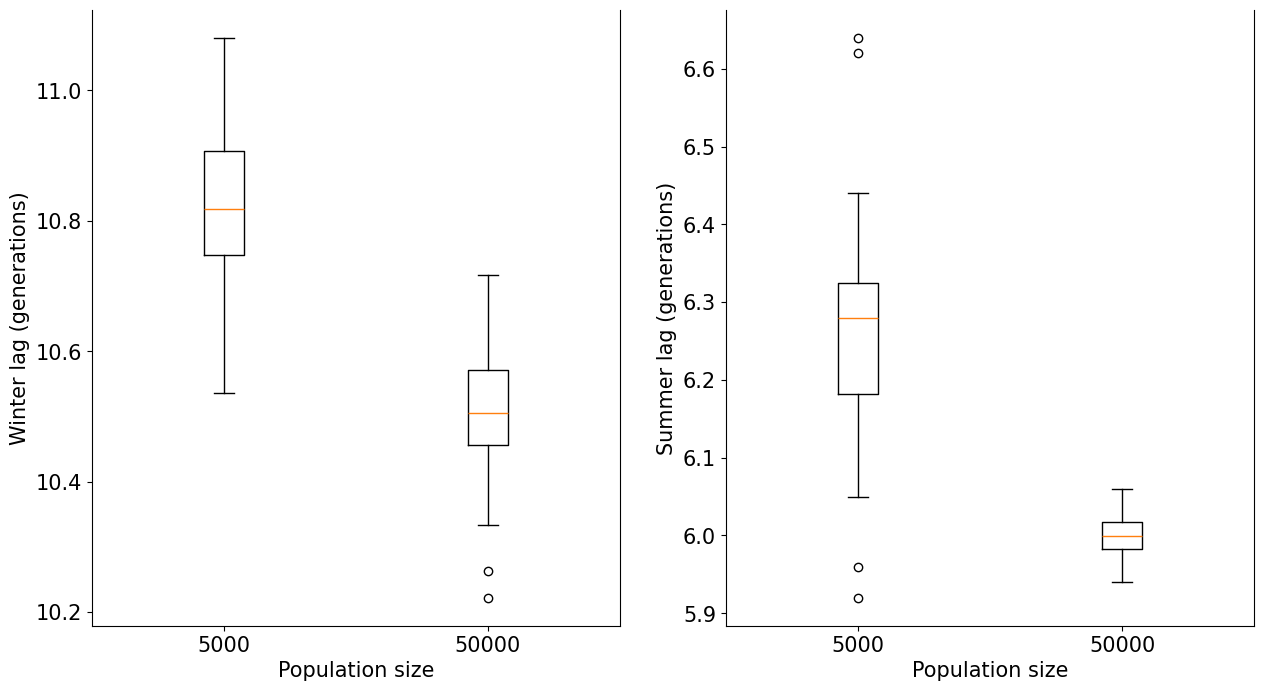

In [ ]:
# Figure 7(b)
sine2_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine2_params.csv")
Ns = [5000, 50_000]
winter_lags = {5000: [], 50_000: []}
summer_lags = {5000: [], 50_000: []}

def measure_lag(row):
    if row.N_POP in Ns:
        log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
        log2 = log[log.cycle - max(log.cycle) > -360 * 10]
        Temp_maxs = scipy.signal.find_peaks(log2.Temp, distance = 30)[0]

        CTmin_maxs = scipy.signal.find_peaks(log2.CTmin_mean, distance = 30, height=log2.CTmin_mean.mean())[0]

        Temp_mins = scipy.signal.find_peaks(-log2.Temp, distance = 30)[0]
        CTmin_mins = scipy.signal.find_peaks(-log2.CTmin_mean, distance = 30, height=-log2.CTmin_mean.mean())[0]
        CTmin_lag_winter = np.mean(CTmin_mins[1:] - Temp_mins[:-1])
        CTmin_lag_summer = np.mean(CTmin_maxs - Temp_maxs)
        winter_lags[row.N_POP].append(CTmin_lag_winter)
        summer_lags[row.N_POP].append(CTmin_lag_summer)


sine2_params.apply(measure_lag, axis=1)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
ax[0].boxplot(winter_lags.values(), tick_labels=winter_lags.keys())
ax[0].set_ylabel('Winter lag (generations)')
ax[0].set_xlabel('Population size')
ax[1].boxplot(summer_lags.values(), tick_labels=summer_lags.keys())
ax[1].set_ylabel('Summer lag (generations)')
ax[1].set_xlabel("Population size")
fig.savefig("../figures/changing_N_lag.png", bbox_inches='tight')

In [ ]:
# Set up for Figure 8 and 9
sine4_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine4_params.csv")

# Oligogenic -> polygenic gradient (MU x QTN_var held so mutational input variance is ~constant
# for the last 3 combos; MU=1e-8/QTN_var=25 is a higher-variance oligogenic extreme). REC=1e-8 for all.
MU_AND_QTN_VAR = [(1e-7, 0.05), (1e-6, 0.005), (1e-5, 0.0005)]
architecture_labels = ['polygenic', 'moderately polygenic', 'highly polygenic']
# architecture_labels = [f"MU={mu}, QTN_var={v}" for mu, v in MU_AND_QTN_VAR]
architecture_colors = ['tab:blue', 'tab:orange', 'tab:green']

def paired_lag(follower_days, leader_days, max_lag=180):
    """Mean number of days each follower peak/trough occurs after the nearest preceding leader
    peak/trough. Peak-finding can return unequal counts near the window edges, so pair by nearest
    preceding occurrence (searchsorted) rather than assuming aligned array positions, and drop any
    unmatched edge peaks (lag outside [0, max_lag])."""
    lags = []
    for d in follower_days:
        idx = np.searchsorted(leader_days, d, side='right') - 1
        if idx < 0:
            continue
        lag = d - leader_days[idx]
        if 0 <= lag <= max_lag:
            lags.append(lag)
    return np.mean(lags)


def measure_metrics(row):
    """Amplitude and winter/summer lag of CTmin relative to Temp, averaged over the last 10 annual cycles."""
    log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
    # last 10 years (1 yr = 360 generations = 3600 days) for a robust multi-cycle average
    log2 = log[log.cycle - max(log.cycle) > -360 * 10]

    Temp_maxs = scipy.signal.find_peaks(log2.Temp, distance=30)[0]
    Temp_mins = scipy.signal.find_peaks(-log2.Temp, distance=30)[0]
    CTmin_maxs = scipy.signal.find_peaks(log2.CTmin_mean, distance=30, height=log2.CTmin_mean.mean())[0]
    CTmin_mins = scipy.signal.find_peaks(-log2.CTmin_mean, distance=30, height=-log2.CTmin_mean.mean())[0]
    CTmax_maxs = scipy.signal.find_peaks(log2.CTmax_mean, distance=30, height=log2.CTmax_mean.mean())[0]
    CTmax_mins = scipy.signal.find_peaks(-log2.CTmax_mean, distance=30, height=-log2.CTmax_mean.mean())[0]

    days = log2.day.values
    ctmin = log2.CTmin_mean.values
    ctmax = log2.CTmax_mean.values
    return pd.Series({
        'CTmin_winter_lag': paired_lag(days[CTmin_mins], days[Temp_mins]),
        'CTmin_summer_lag': paired_lag(days[CTmin_maxs], days[Temp_maxs]),
        'CTmin_amplitude': np.mean(ctmin[CTmin_maxs]) - np.mean(ctmin[CTmin_mins]),
        'CTmax_winter_lag': paired_lag(days[CTmax_mins], days[Temp_mins]),
        'CTmax_summer_lag': paired_lag(days[CTmax_maxs], days[Temp_maxs]),
        'CTmax_amplitude': np.mean(ctmax[CTmax_maxs]) - np.mean(ctmax[CTmax_mins]),

    })

# --- Effect of polygenicity (REC held at 1e-8), one box per architecture, one point per seed ---
architecture_metrics = {label: {'CTmin_amplitude': [], 
                                'CTmin_winter_lag': [], 
                                'CTmin_summer_lag': [], 
                                'CTmax_amplitude': [], 
                                'CTmax_winter_lag': [], 
                                'CTmax_summer_lag': []} for label in architecture_labels}
for (mu, qtn_var), label in zip(MU_AND_QTN_VAR, architecture_labels):
    rows = sine4_params[(sine4_params.MU == mu) & (sine4_params.QTN_var == qtn_var) & (sine4_params.RECOMBINATION_RATE == 1e-8)]
    for _, row in rows.iterrows():
        m = measure_metrics(row)
        for key in ('CTmin_amplitude', 'CTmin_winter_lag', 'CTmin_summer_lag', 'CTmax_amplitude', 'CTmax_winter_lag', 'CTmax_summer_lag'):
            architecture_metrics[label][key].append(m[key])

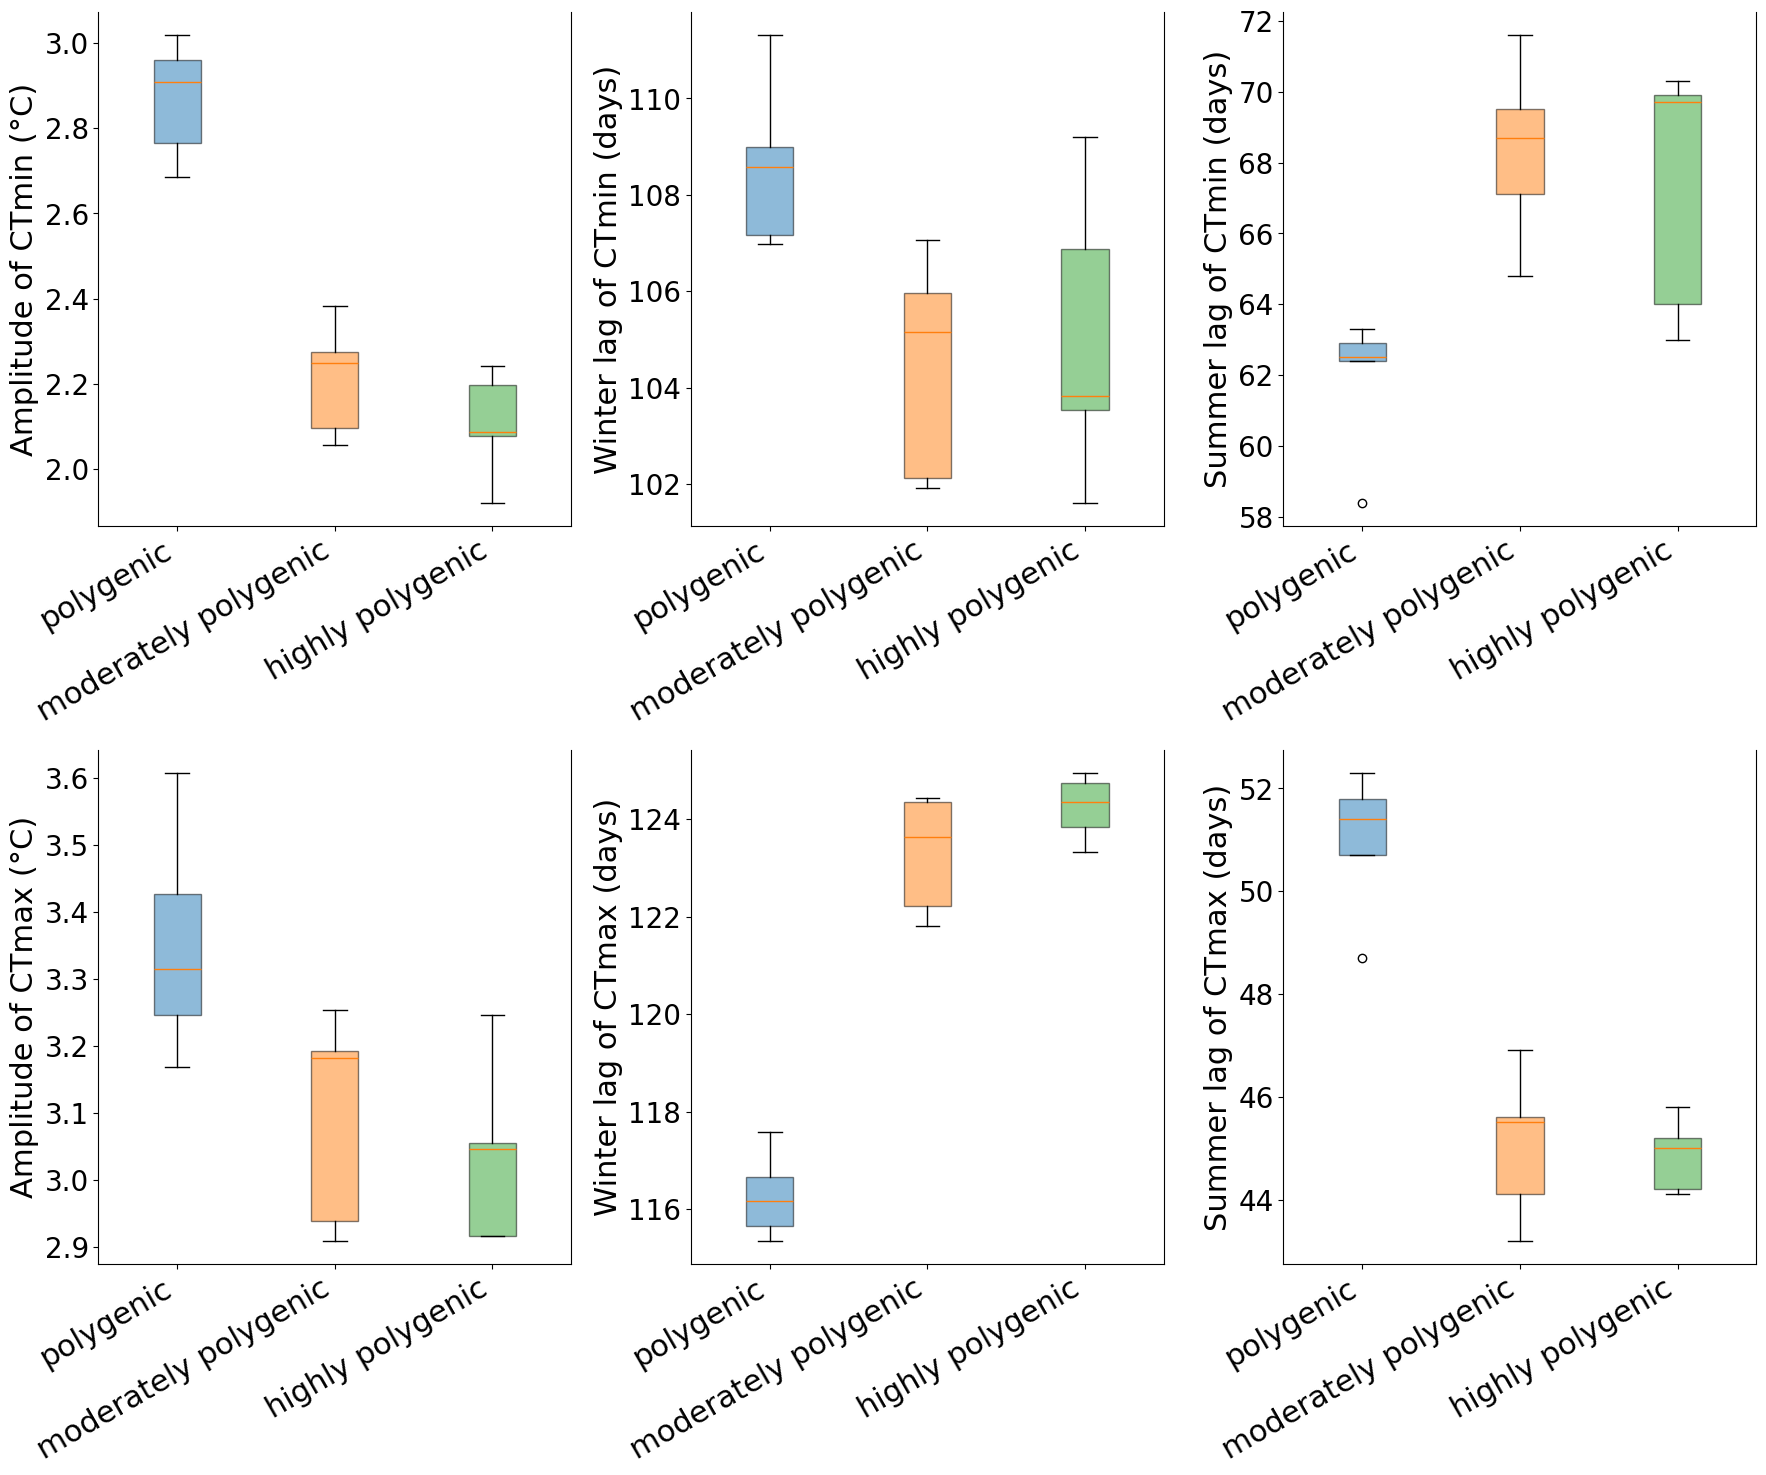

In [ ]:
# Figure 8
metric_titles = [('CTmin_amplitude', 'Amplitude of CTmin (°C)'), 
                 ('CTmin_winter_lag', 'Winter lag of CTmin (days)'), 
                 ('CTmin_summer_lag', 'Summer lag of CTmin (days)'), 
                 ('CTmax_amplitude', 'Amplitude of CTmax (°C)'), 
                 ('CTmax_winter_lag', 'Winter lag of CTmax (days)'), 
                 ('CTmax_summer_lag', 'Summer lag of CTmax (days)')]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 15))
for i, (key, ylabel) in enumerate(metric_titles):
    bp = ax.flat[i].boxplot([architecture_metrics[label][key] for label in architecture_labels],
                        tick_labels=architecture_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], architecture_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.flat[i].set_ylabel(ylabel, fontsize=22)
    ax.flat[i].tick_params(axis='y', labelsize=20)
    ax.flat[i].tick_params(axis='x', labelsize=22, labelrotation=30)
    for tick in ax.flat[i].get_xticklabels():
        tick.set_ha('right')
fig.tight_layout()
fig.savefig("../figures/sine4_polygenicity_boxplot.pdf")

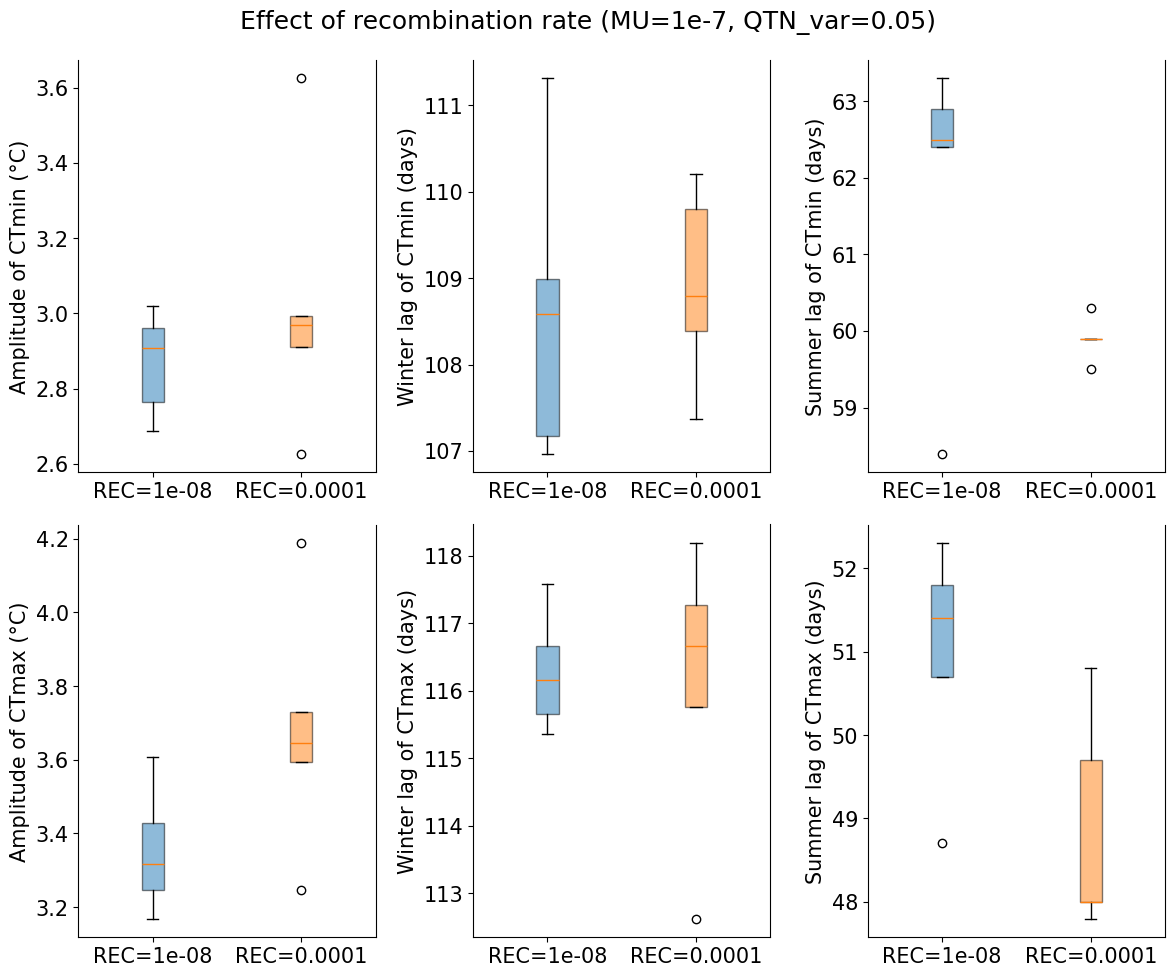

In [ ]:
# Figure 9
# --- Effect of recombination rate, holding genetic architecture fixed at MU=1e-7, QTN_var=0.05 ---
REC_variants = [1e-8, 1e-4]
recomb_labels = [f"REC={r}" for r in REC_variants]
recomb_colors = ['tab:blue', 'tab:orange']
recomb_metrics = {label: {'CTmin_amplitude': [], 
                                'CTmin_winter_lag': [], 
                                'CTmin_summer_lag': [], 
                                'CTmax_amplitude': [], 
                                'CTmax_winter_lag': [], 
                                'CTmax_summer_lag': []} for label in recomb_labels}


for r, label in zip(REC_variants, recomb_labels):
    rows = sine4_params[(sine4_params.MU == 1e-7) & (sine4_params.QTN_var == 0.05) & (sine4_params.RECOMBINATION_RATE == r)]
    for _, row in rows.iterrows():
        m = measure_metrics(row)
        for key in ('CTmin_amplitude', 'CTmin_winter_lag', 'CTmin_summer_lag', 'CTmax_amplitude', 'CTmax_winter_lag', 'CTmax_summer_lag'):
            recomb_metrics[label][key].append(m[key])

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))
fig.suptitle("Effect of recombination rate (MU=1e-7, QTN_var=0.05)")
for i, (key, ylabel) in enumerate(metric_titles):
    bp = ax.flat[i].boxplot([recomb_metrics[label][key] for label in recomb_labels],
                        tick_labels=recomb_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], recomb_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.flat[i].set_ylabel(ylabel)
fig.tight_layout()
fig.savefig("../figures/sine4_recomb_boxplot.pdf")

B=23.1492
CTmin=1.81624
B summer=23.3291
CTmin=2.23055


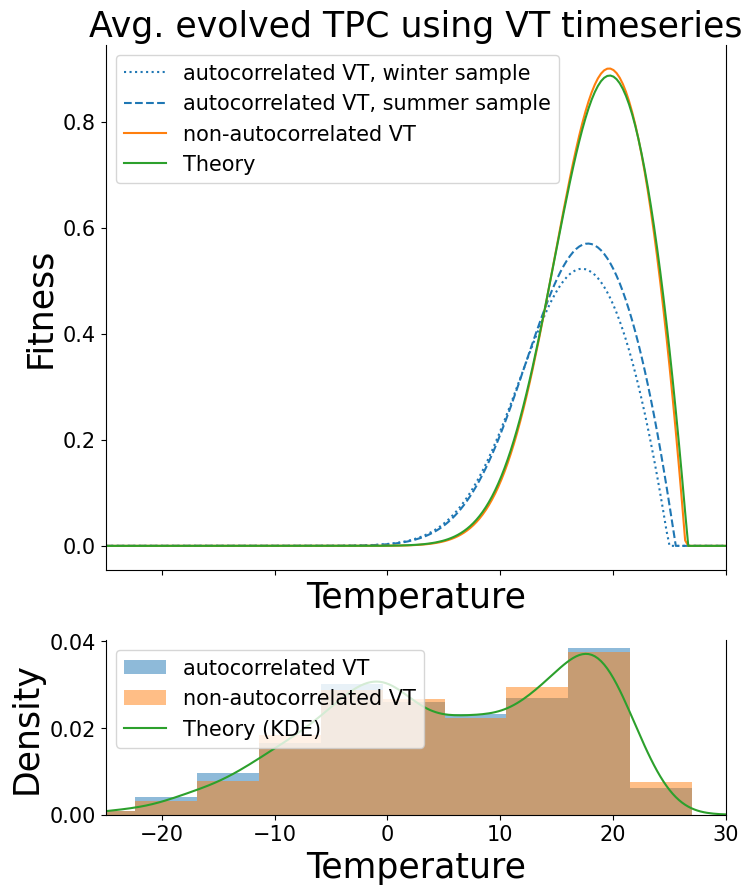

In [ ]:
# Figure 10
# prepare theoretical prediction
# First import time-series data and fit a Gaussian KDE
vt_temp = pd.read_csv("../slim/VT_weather.txt").T2M
kernel = scipy.stats.gaussian_kde(vt_temp)

# Modify w_TPC functions to predict optimal TPC from an arbitrary kernel
def expected_w_TPC_temp_series(temp_series, CTmin, B):
    '''
    Expected TPC given temperature list, assuming reproductive output per day after heat damage is zero (no-recovery model).
    The expected value is derived in the SI of the manuscript. 
    In short, it involves calculating probability that the temperature stays under lethal limit for various number of days.
    '''
    # update params to match the simulation
    tpc_object.num_days_per_gen = 21 
    nr = tpc_object.num_days_per_gen
    tpc_object.CTmin_critical = 1.5
    tpc_object.B_critical = 30

    CTmin_array = np.array(CTmin, ndmin=1)
    B_array = np.array(B, ndmin=1)
    
    kernel = scipy.stats.gaussian_kde(temp_series)
    CTmin_grid, B_grid = np.meshgrid(CTmin_array, B_array)
    output = np.zeros(CTmin_grid.shape)
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            CTmin = CTmin_grid[i,j]
            B = B_grid[i,j]
            CTmax = CTmin + B
            fun = lambda T: tpc_object.w_TPC(T=T, CTmin=CTmin, B=B) * kernel.pdf(T)
            integral, err = scipy.integrate.quad(fun, CTmin, CTmax)
            r = kernel.integrate_box_1d(min(temp_series) - 10, CTmax)
            if (1 - r) < np.finfo(np.float64).tiny:
                C = 1
            else:
                C = (1 - nr * r ** (nr - 1) + (-1 + nr) * r ** nr) / (nr * (1 - r)) + r ** (nr - 1)
            output[i,j] = C * integral
    return output

def optimize_expected_w_TPC_temp_series(temp_series, CTmin0, B0):
    '''
    Find optimal CTmin and B that maximize expected w_TPC using no-recovery model.
    CTmin0 and B0 are initial guess
    '''
    B_tiny = 1e-3
    def objective(params):
        CTmin, B = params
        expected_w_TPC = expected_w_TPC_temp_series(temp_series=temp_series, B=B, CTmin=CTmin)
        return -expected_w_TPC
    bnds = ((None, None), (B_tiny, None))
    results = scipy.optimize.minimize(objective, [CTmin0, B0], method='L-BFGS-B', bounds=bnds)
    return results.x
CTmin_opt, B_opt = optimize_expected_w_TPC_temp_series(vt_temp, 5, 10)


log_new = pd.read_csv(f"{datadir}VT_autocorrelated_0.txt")
log2 = pd.read_csv(f"{datadir}VT_scrambled.txt")
Tlist = np.linspace(-25, 30, 200)
fig, ax = plt.subplots(figsize=(8,10), nrows=2, ncols=1, height_ratios=[3, 1], sharex=True)
# number of generations before the end of simulation to sample
sample1=32
sample2=23
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log_new.B_mean)[-1-sample1], 
        CTmin=np.array(log_new.CTmin_mean)[-1-sample1], 
        T=Tlist),
    color='tab:blue',
    linestyle='dotted',
    label=f'autocorrelated VT, winter sample')
print(f"B={np.array(log_new.B_mean)[-1-sample1]}")
print(f"CTmin={np.array(log_new.CTmin_mean)[-1-sample1]}")
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log_new.B_mean)[-1-sample2], 
        CTmin=np.array(log_new.CTmin_mean)[-1-sample2], 
        T=Tlist),
    linestyle='--',
    label=f'autocorrelated VT, summer sample')

print(f"B summer={np.array(log_new.B_mean)[-1-sample2]}")
print(f"CTmin={np.array(log_new.CTmin_mean)[-1-sample2]}")
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log2.B_mean)[-1], 
        CTmin=np.array(log2.CTmin_mean)[-1], 
        T=Tlist),
    label='non-autocorrelated VT')
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=B_opt, CTmin=CTmin_opt, T=Tlist), 
    label='Theory')
ax[0].set_xlim((Tlist[0], Tlist[-1]))
ax[0].set_title("Avg. evolved TPC using VT timeseries", fontsize=25)
ax[0].set_xlabel("Temperature", fontsize=25)
ax[0].set_ylabel("Fitness", fontsize=25)
ax[0].legend()
ax[1].hist(log_new.Temp, density=True, label='autocorrelated VT', alpha=0.5)
ax[1].hist(log2.Temp, density=True, label='non-autocorrelated VT', alpha=0.5)
ax[1].plot(Tlist, kernel.pdf(Tlist), label='Theory (KDE)')
ax[1].set_xlabel("Temperature", fontsize=25)
ax[1].set_ylabel("Density", fontsize=25)
ax[1].set_xlim((Tlist[0], Tlist[-1]))
ax[1].legend()
fig.savefig('../figures/vt-autocorrelation.pdf', bbox_inches='tight')

In [ ]:
# Save path to all data files needed for this script
datadir = os.path.abspath("../data")
needed = sorted(p for p in _accessed if p.startswith(datadir))
with open("../data/data_for_main_figures.txt", "w") as f:
    f.write("\n".join(os.path.relpath(p, datadir) for p in needed))